# 03 — Análisis Exploratorio de Datos (EDA)

Este notebook explora el dataset limpio de permisos de circulación para:
- Entender la distribución de cada variable
- Identificar relaciones entre features y la variable target (`estado`)
- Detectar patrones temporales
- Informar decisiones de feature engineering y modelado

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from config.config import CLEAN_FILE

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv(CLEAN_FILE)
df['fecha_emision'] = pd.to_datetime(df['fecha_emision'])
print(f"Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dataset: 4950 filas x 9 columnas


,id_permiso,tipo_vehiculo,fecha_emision,duracion_dias,zona_circulacion,monto_pagado,renovacion,infracciones_previas,estado
0,1,Furgoneta,2025-05-24,28.0,Zona D,102875.69,False,1,Inactivo
1,2,Bicicleta,2025-05-10,20.0,Zona C,6341.74,False,0,Activo
2,3,Camion,2025-02-08,5.0,Zona A,92238.12,False,1,Inactivo
3,4,Bicicleta,2024-11-22,8.0,Zona D,9604.68,False,1,Inactivo
4,5,Bicicleta,2024-11-03,12.0,Zona D,9292.32,False,2,Activo


## 1. Distribución de la variable target

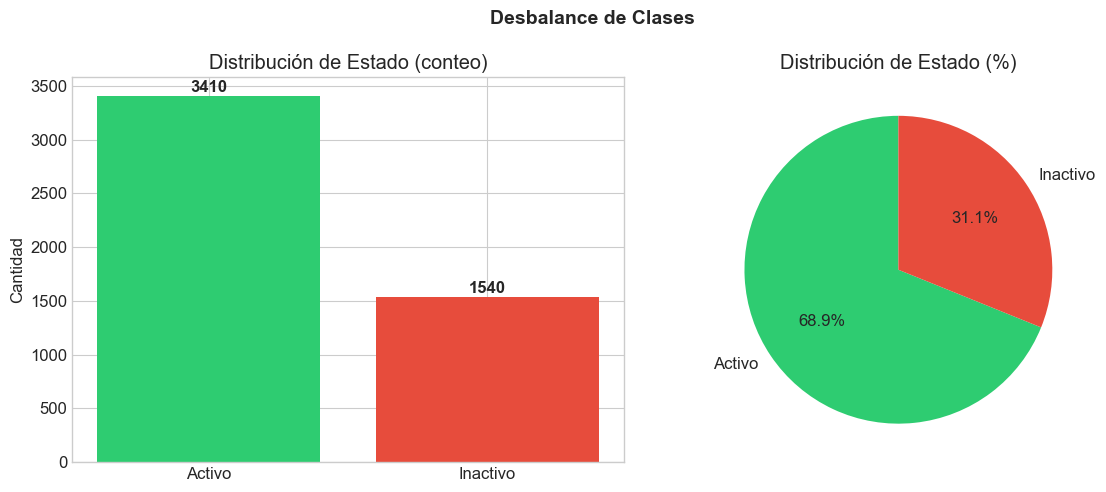

Ratio Activo:Inactivo = 2.21:1


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Conteo absoluto
estado_counts = df['estado'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(estado_counts.index, estado_counts.values, color=colors)
axes[0].set_title('Distribución de Estado (conteo)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(estado_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Proporción
axes[1].pie(estado_counts.values, labels=estado_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Distribución de Estado (%)')

plt.suptitle('Desbalance de Clases', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Ratio Activo:Inactivo = {estado_counts['Activo']/estado_counts['Inactivo']:.2f}:1")

## 2. Distribución de variables numéricas

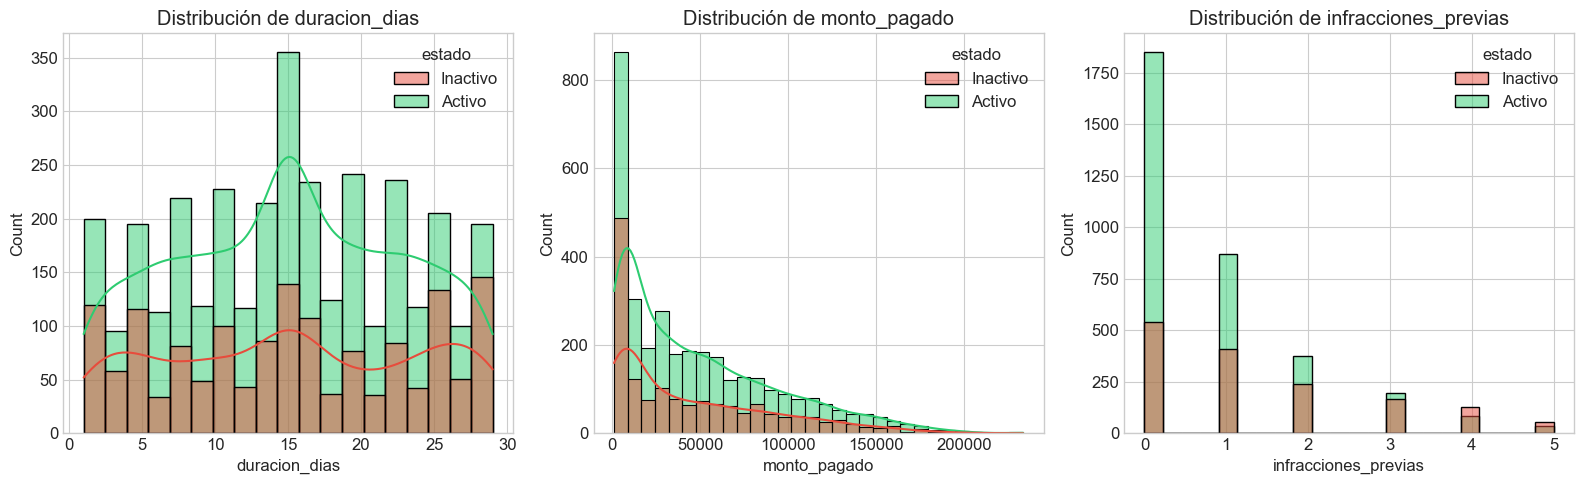

In [3]:
num_cols = ['duracion_dias', 'monto_pagado', 'infracciones_previas']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='estado', kde=(col != 'infracciones_previas'),
                 ax=axes[i], palette={'Activo': '#2ecc71', 'Inactivo': '#e74c3c'})
    axes[i].set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

In [4]:
# Estadísticas descriptivas por estado
print("=== Estadísticas por Estado ===")
df.groupby('estado')[num_cols].agg(['mean', 'median', 'std']).round(2)

=== Estadísticas por Estado ===


duracion_dias              monto_pagado                      \
                  mean median   std         mean    median       std   
estado                                                                 
Activo           15.07   15.0  7.86     48490.48  34639.19  44837.03   
Inactivo         15.24   15.0  8.66     45737.54  30370.57  44836.74   

         infracciones_previas               
                         mean median   std  
estado                                      
Activo                   0.80    0.0  1.11  
Inactivo                 1.41    1.0  1.45

## 3. Análisis de variables categóricas vs estado

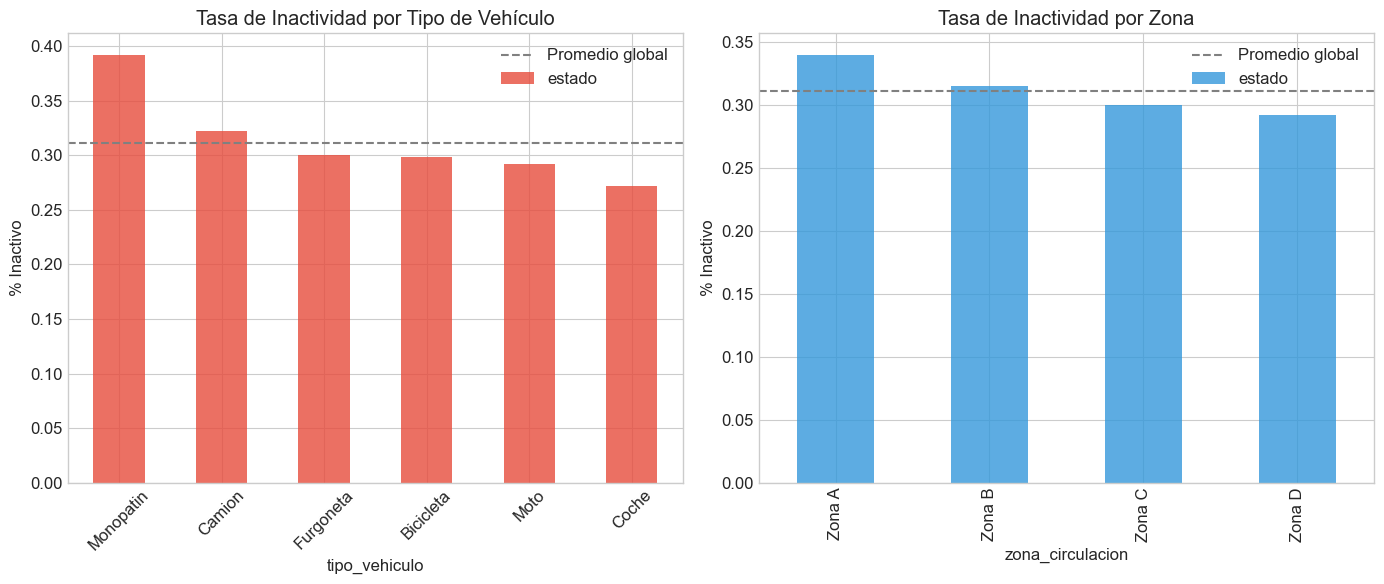

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Tasa de inactivos por tipo de vehículo
tasa_tipo = df.groupby('tipo_vehiculo')['estado'].apply(
    lambda x: (x == 'Inactivo').mean()
).sort_values(ascending=False)

tasa_tipo.plot(kind='bar', ax=axes[0], color='#e74c3c', alpha=0.8)
axes[0].set_title('Tasa de Inactividad por Tipo de Vehículo')
axes[0].set_ylabel('% Inactivo')
axes[0].axhline(y=df['estado'].eq('Inactivo').mean(), color='gray', linestyle='--', label='Promedio global')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Tasa de inactivos por zona
tasa_zona = df.groupby('zona_circulacion')['estado'].apply(
    lambda x: (x == 'Inactivo').mean()
).sort_values(ascending=False)

tasa_zona.plot(kind='bar', ax=axes[1], color='#3498db', alpha=0.8)
axes[1].set_title('Tasa de Inactividad por Zona')
axes[1].set_ylabel('% Inactivo')
axes[1].axhline(y=df['estado'].eq('Inactivo').mean(), color='gray', linestyle='--', label='Promedio global')
axes[1].legend()

plt.tight_layout()
plt.show()

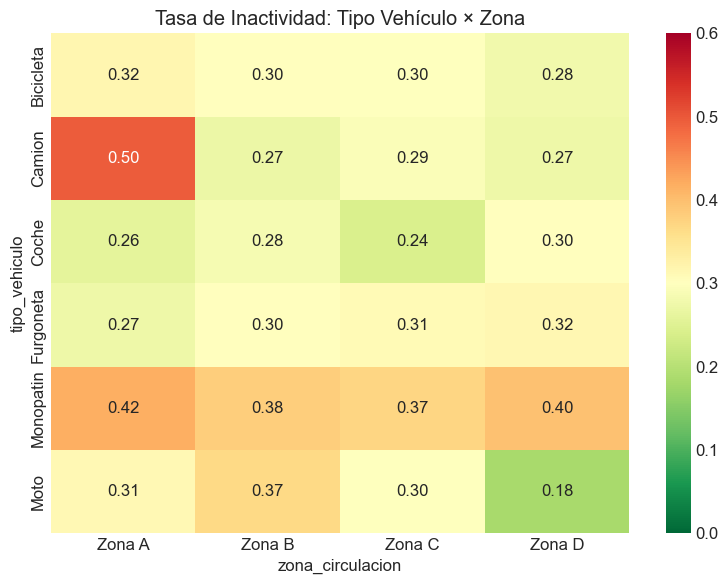

In [6]:
# Heatmap: tipo_vehiculo vs zona_circulacion (tasa de inactivos)
pivot = df.pivot_table(
    values='estado',
    index='tipo_vehiculo',
    columns='zona_circulacion',
    aggfunc=lambda x: (x == 'Inactivo').mean()
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', vmin=0, vmax=0.6)
plt.title('Tasa de Inactividad: Tipo Vehículo × Zona')
plt.tight_layout()
plt.show()

## 4. Análisis temporal

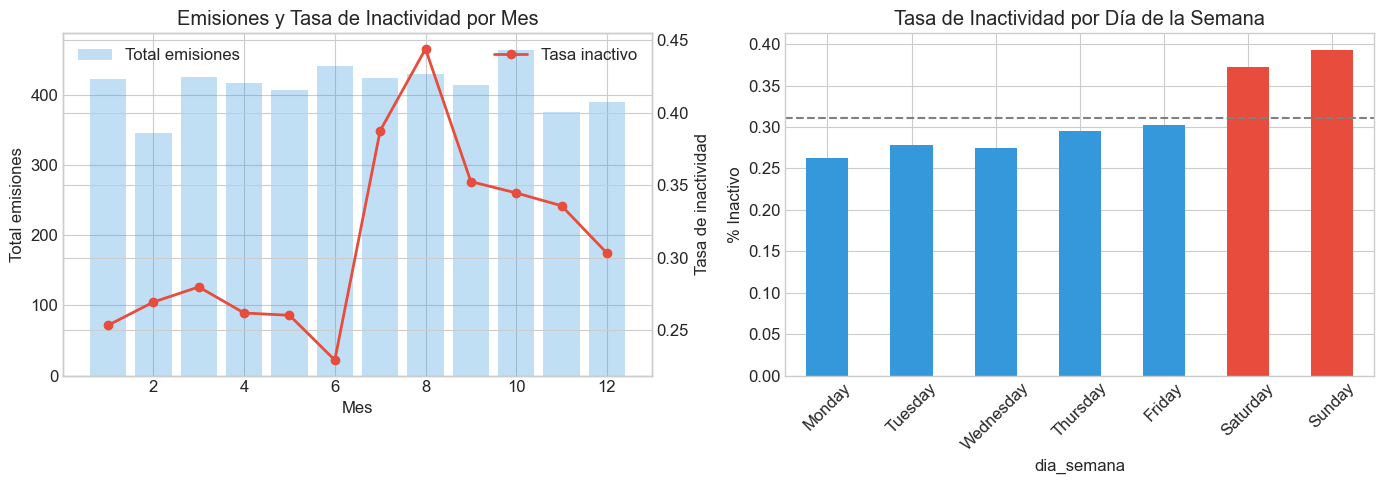

In [7]:
df['mes'] = df['fecha_emision'].dt.month
df['dia_semana'] = df['fecha_emision'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Emisiones por mes
monthly = df.groupby('mes').agg(
    total=('estado', 'count'),
    tasa_inactivo=('estado', lambda x: (x == 'Inactivo').mean())
)

ax2 = axes[0].twinx()
axes[0].bar(monthly.index, monthly['total'], alpha=0.3, color='#3498db', label='Total emisiones')
ax2.plot(monthly.index, monthly['tasa_inactivo'], color='#e74c3c', marker='o', linewidth=2, label='Tasa inactivo')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Total emisiones')
ax2.set_ylabel('Tasa de inactividad')
axes[0].set_title('Emisiones y Tasa de Inactividad por Mes')
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

# Tasa por día de la semana
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
tasa_dia = df.groupby('dia_semana')['estado'].apply(
    lambda x: (x == 'Inactivo').mean()
).reindex(dias_orden)

colors_dia = ['#3498db'] * 5 + ['#e74c3c'] * 2  # rojo para fin de semana
tasa_dia.plot(kind='bar', ax=axes[1], color=colors_dia)
axes[1].set_title('Tasa de Inactividad por Día de la Semana')
axes[1].set_ylabel('% Inactivo')
axes[1].axhline(y=df['estado'].eq('Inactivo').mean(), color='gray', linestyle='--')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Infracciones previas vs Estado

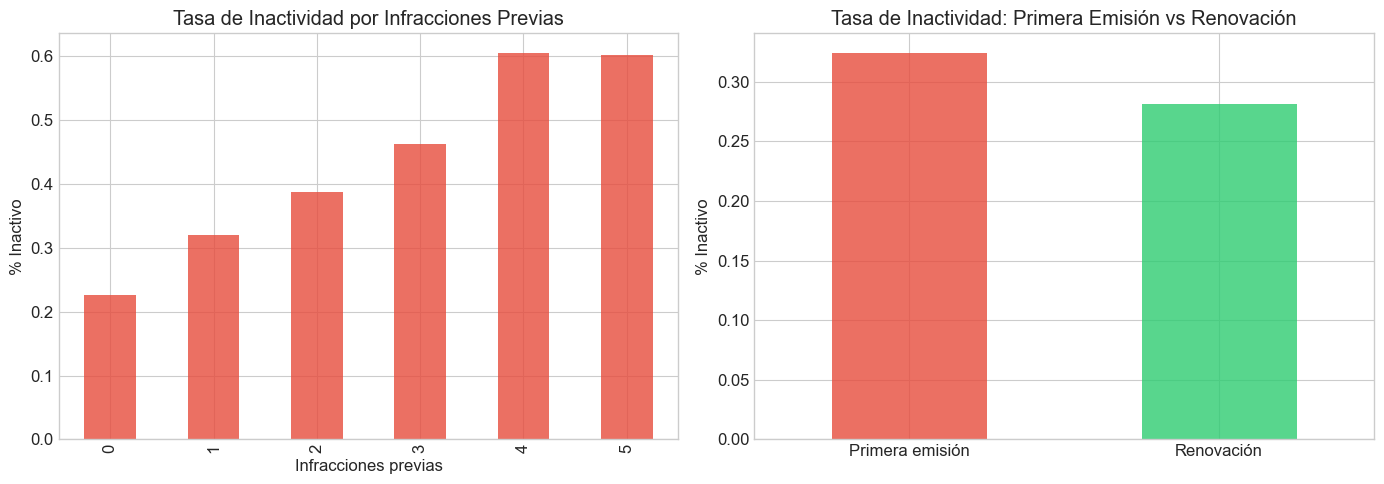

In [8]:
tasa_infr = df.groupby('infracciones_previas')['estado'].apply(
    lambda x: (x == 'Inactivo').mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tasa_infr.plot(kind='bar', ax=axes[0], color='#e74c3c', alpha=0.8)
axes[0].set_title('Tasa de Inactividad por Infracciones Previas')
axes[0].set_ylabel('% Inactivo')
axes[0].set_xlabel('Infracciones previas')

# Renovación vs estado
tasa_renov = df.groupby('renovacion')['estado'].apply(
    lambda x: (x == 'Inactivo').mean()
)
tasa_renov.index = ['Primera emisión', 'Renovación']
tasa_renov.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], alpha=0.8)
axes[1].set_title('Tasa de Inactividad: Primera Emisión vs Renovación')
axes[1].set_ylabel('% Inactivo')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 6. Correlaciones

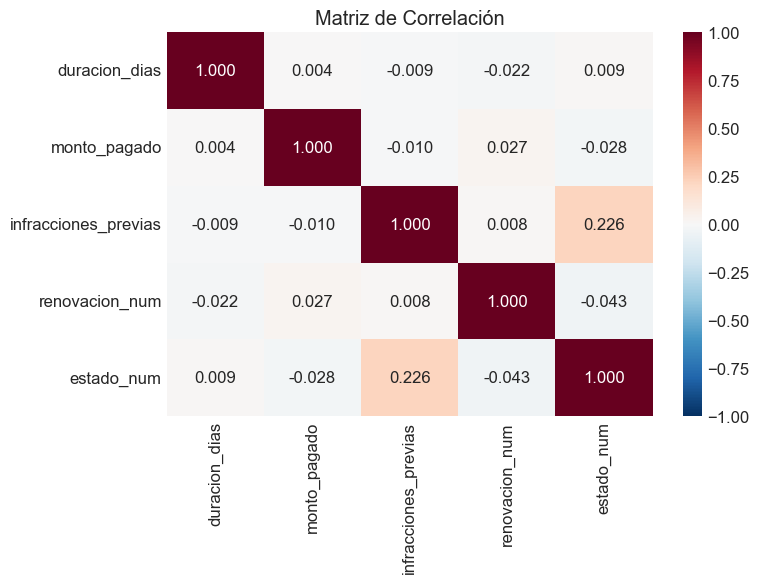


Correlación con estado (Inactivo=1):
infracciones_previas    0.226
duracion_dias           0.009
monto_pagado           -0.028
renovacion_num         -0.043
Name: estado_num, dtype: float64


In [9]:
# Crear variable numérica para estado
df_corr = df.copy()
df_corr['estado_num'] = (df_corr['estado'] == 'Inactivo').astype(int)
df_corr['renovacion_num'] = df_corr['renovacion'].astype(int)

cols_corr = ['duracion_dias', 'monto_pagado', 'infracciones_previas', 'renovacion_num', 'estado_num']
corr_matrix = df_corr[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

print("\nCorrelación con estado (Inactivo=1):")
print(corr_matrix['estado_num'].drop('estado_num').sort_values(ascending=False).round(3))

## 7. Resumen de hallazgos

**Hallazgos clave para el modelado:**

1. **Desbalance de clases**: ~69% Activo vs ~31% Inactivo → necesitaremos técnicas de balanceo (SMOTE, class_weight)
2. **Infracciones previas**: predictor más fuerte — a más infracciones, mayor tasa de inactividad
3. **Tipo de vehículo**: Monopatines y Camiones muestran mayor tasa de inactividad
4. **Interacción tipo × zona**: Camiones en Zona A tienen la tasa más alta (patrón de zona restringida)
5. **Fin de semana**: permisos emitidos en sábado/domingo tienen mayor tasa de inactividad
6. **Renovación**: los permisos renovados son más estables (menor inactividad)
7. **Monto pagado**: correlación negativa con inactividad (montos bajos → más inactivos)

Estos patrones confirman que las features tienen poder predictivo real sobre el estado.